# Import necessary libraries

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import LineString
import utm
from sklearn.preprocessing import StandardScaler
import math

# Remove warning 

In [29]:
import warnings
warnings.filterwarnings("ignore")

# Read Dataset

In [39]:
Data_folder = 'Dataset'

# Read  data
data_files = [os.path.join(Data_folder, file) for file in os.listdir(Data_folder) if file.endswith('.csv')]
df = pd.concat([pd.read_csv(file) for file in data_files], ignore_index=True)

In [40]:
df.shape

(70998, 186)

# List the Features

In [41]:
column_names = df.columns.tolist()
print("Column Names:")
for column_name in column_names:
    print(column_name)

Column Names:
CUSTOM.date [local]
CUSTOM.updateTime [local]
OSD.flyTime
OSD.flyTime [s]
OSD.latitude
OSD.longitude
OSD.height [ft]
OSD.heightMax [ft]
OSD.vpsHeight [ft]
OSD.altitude [ft]
OSD.mileage [ft]
OSD.hSpeed [MPH]
OSD.hSpeedMax [MPH]
OSD.xSpeed [MPH]
OSD.xSpeedMax [MPH]
OSD.ySpeed [MPH]
OSD.ySpeedMax [MPH]
OSD.zSpeed [MPH]
OSD.zSpeedMax [MPH]
OSD.pitch
OSD.roll
OSD.yaw
OSD.yaw [360]
OSD.flycState
OSD.flycCommand
OSD.flightAction
OSD.gpsNum
OSD.gpsLevel
OSD.isGPSUsed
OSD.nonGPSCause
OSD.droneType
OSD.isSwaveWork
OSD.waveError
OSD.goHomeStatus
OSD.batteryType
OSD.ctrlDevice
OSD.isOnGround
OSD.isMotorOn
OSD.isMotorBlocked
OSD.motorStartFailedCause
OSD.motorFailReason
OSD.isImuPreheated
OSD.imuInitFailReason
OSD.isAcceletorOverRange
OSD.isBarometerDeadInAir
OSD.isCompassError
OSD.isGoHomeHeightModified
OSD.canIOCWork
OSD.isNotEnoughForce
OSD.isOutOfLimit
OSD.isPropellerCatapult
OSD.isVibrating
OSD.isVisionUsed
OSD.voltageWarning
GIMBAL.mode
GIMBAL.pitch
GIMBAL.roll
GIMBAL.yaw
GIMBAL

# Feature Selection

In [42]:
features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder','OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

In [43]:
df=df[features]
df

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
0,0m 0.0s,1024,1024,1024,1024,80.353166,7.498430,0.0,5.7,2.5,113.9
1,0m 0.1s,1024,1024,1024,1024,80.353166,7.498430,0.0,5.7,2.5,114.0
2,0m 0.2s,1024,1024,1024,1024,80.353166,7.498430,0.0,5.7,2.5,114.0
3,0m 0.3s,1024,1024,1024,1024,80.353166,7.498430,0.0,5.7,2.5,114.0
4,0m 0.4s,1024,1024,1024,1024,80.353166,7.498429,0.0,5.7,2.5,114.1
...,...,...,...,...,...,...,...,...,...,...,...
70993,12m 15.1s,1024,1024,364,1024,79.914412,6.974626,2.2,2.2,-2.0,-168.8
70994,12m 15.2s,1024,1024,364,1024,79.914412,6.974626,2.2,2.5,-2.5,-169.0
70995,12m 15.3s,1024,1024,364,1024,79.914412,6.974626,2.2,2.5,-1.7,-169.2
70996,12m 15.4s,1024,1024,364,1024,79.914412,6.974626,2.2,2.7,-1.4,-169.5


# Convert time string to seconds function

In [44]:
def time_to_seconds(time_str):
    # Split the time string by space
    time_parts = time_str.split()
    
    # Extract minutes and seconds
    minutes = float(time_parts[0][:-1])  # Remove 'm' and convert to float
    seconds = float(time_parts[1][:-1])  # Remove 's' and convert to float
    
    # Convert to seconds
    total_seconds = (minutes * 60) + seconds
    return total_seconds

# Preprocess 'OSD.flyTime' column
df['OSD.flyTime'] = df['OSD.flyTime'].apply(time_to_seconds)


# Data Analysis

# Range of each features

Range of values for each feature:
                        min          max
OSD.flyTime        0.000000  1176.300000
RC.aileron       364.000000  1684.000000
RC.elevator      364.000000  1684.000000
RC.throttle      364.000000  1684.000000
RC.rudder        364.000000  1684.000000
OSD.longitude     79.913877    80.353385
OSD.latitude       6.972471     7.498461
OSD.height [ft]   -6.800000   115.800000
OSD.pitch        -23.600000    27.400000
OSD.roll         -19.600000    22.300000
OSD.yaw         -179.900000   179.900000


<Figure size 1200x600 with 0 Axes>

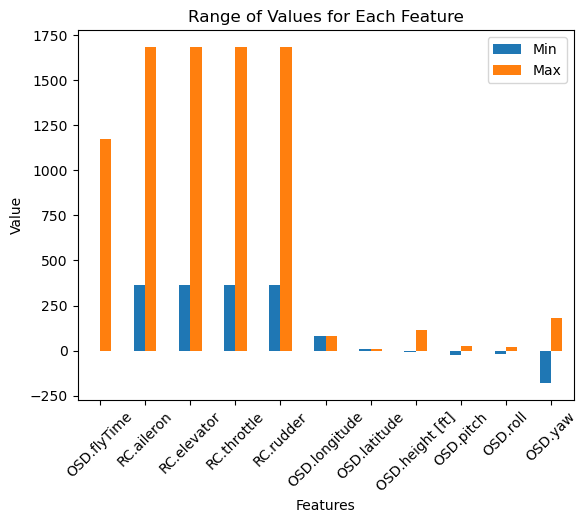

In [45]:
feature_ranges = df.describe().loc[['min', 'max']]

# Transpose the DataFrame for easier plotting
feature_ranges = feature_ranges.transpose()

print("Range of values for each feature:")
print(feature_ranges)
# Plot the range of values for each feature
plt.figure(figsize=(12, 6))
feature_ranges.plot(kind='bar', rot=45)
plt.title('Range of Values for Each Feature')
plt.xlabel('Features')
plt.ylabel('Value')
plt.legend(['Min', 'Max'])
plt.show()

In [46]:
# Calculate summary statistics for the dataset
summary_stats = df.describe()

# Display the summary statistics
summary_stats

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
count,70998.000000,70998.000000,70998.000000,70998.000000,70998.000000,70998.000000,70998.000000,70998.000000,70998.000000,70998.000000,70998.000000
mean,404.971513,1023.433984,1147.451970,991.788346,1028.267867,79.930664,6.992990,9.778288,0.766685,-0.637332,6.976235
std,279.644152,39.258057,230.800692,236.144737,230.265453,0.082023,0.098089,17.662508,4.150309,2.208373,93.060045
min,0.000000,364.000000,364.000000,364.000000,364.000000,79.913877,6.972471,-6.800000,-23.600000,-19.600000,-179.900000
25%,161.525000,1024.000000,1024.000000,1024.000000,1024.000000,79.914192,6.973140,1.900000,-1.100000,-1.500000,-55.800000
50%,370.300000,1024.000000,1024.000000,1024.000000,1024.000000,79.914397,6.974223,3.900000,1.100000,-0.500000,0.100000
75%,622.800000,1024.000000,1271.000000,1024.000000,1024.000000,79.915771,6.974498,8.500000,2.500000,0.300000,73.600000
max,1176.300000,1684.000000,1684.000000,1684.000000,1684.000000,80.353385,7.498461,115.800000,27.400000,22.300000,179.900000


# Convert latitude and longitude into Cartesian coordinates

In [47]:
import pandas as pd
import math

# Define a function to convert latitude and longitude to local Cartesian coordinates
def convert_to_cartesian(row, origin_lat, origin_lon):
    # Calculate the differences between the current point and the origin
    delta_lat = row['OSD.latitude'] - origin_lat
    delta_lon = row['OSD.longitude'] - origin_lon
    
    # Convert the differences to meters using an appropriate conversion factor
    # For simplicity, assuming 1 degree of latitude = 111.32 km and 1 degree of longitude = 111.32 km * cos(latitude)
    lat_to_m = 111320.0  # meters per degree of latitude at the equator
    lon_to_m = 111320.0 * abs(math.cos(math.radians(origin_lat)))  # meters per degree of longitude
    
    # Calculate the x and y coordinates in meters
    x = delta_lon * lon_to_m
    y = delta_lat * lat_to_m
    
    return pd.Series([x, y])  # Return a Series with two values

# Assume 'df' is your DataFrame with columns 'OSD.latitude' and 'OSD.longitude'
# Define your local projection origin point
origin_lat = df['OSD.latitude'].iloc[0]  # Latitude of the first point in the DataFrame
origin_lon = df['OSD.longitude'].iloc[0]  # Longitude of the first point in the DataFrame

# Apply the conversion function to each row and create new columns for local Cartesian coordinates
df[['local_x', 'local_y']] = df.apply(convert_to_cartesian, args=(origin_lat, origin_lon), axis=1)

# Scale the Cartesian coordinates between -1 and 1 using Min-Max scaling
df['OSD.latitude'] = 2 * (df['local_x'] - df['local_x'].min()) / (df['local_x'].max() - df['local_x'].min()) - 1
df['OSD.longitude'] = 2 * (df['local_y'] - df['local_y'].min()) / (df['local_y'].max() - df['local_y'].min()) - 1

# Drop the 'local_x' and 'local_y' columns
df.drop(columns=['local_x', 'local_y'], inplace=True)

# Print the DataFrame
df.head()


,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
0,0.0,1024,1024,1024,1024,0.999882,0.999001,0.0,5.7,2.5,113.9
1,0.1,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
2,0.2,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
3,0.3,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.0
4,0.4,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.1


# Data Cleaning

### Remove Null values

In [48]:
null_counts = df.isnull().sum(axis=0)
print(null_counts)

OSD.flyTime        0
RC.aileron         0
RC.elevator        0
RC.throttle        0
RC.rudder          0
OSD.longitude      0
OSD.latitude       0
OSD.height [ft]    0
OSD.pitch          0
OSD.roll           0
OSD.yaw            0
dtype: int64


## Identify Outliers

<Figure size 1500x1000 with 0 Axes>

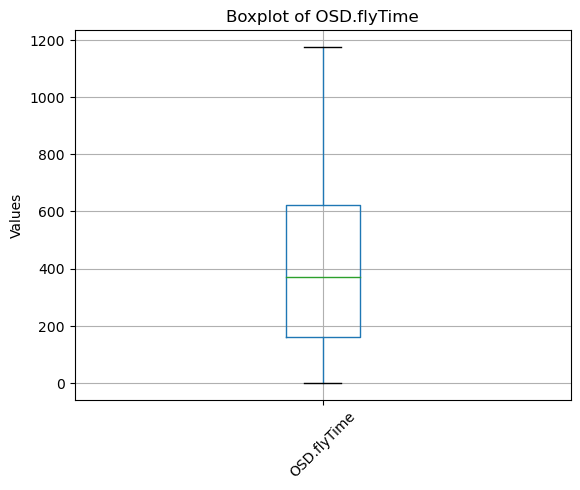

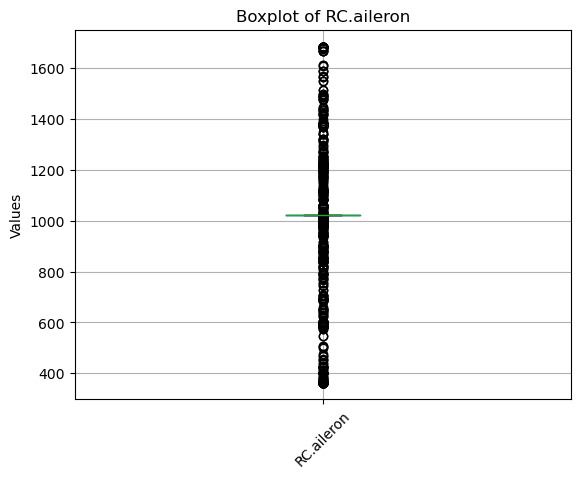

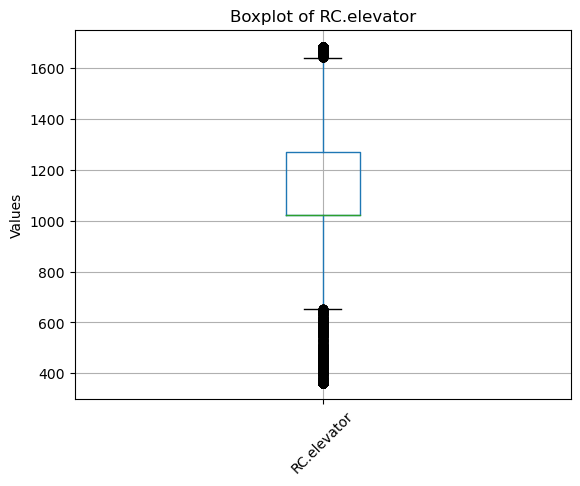

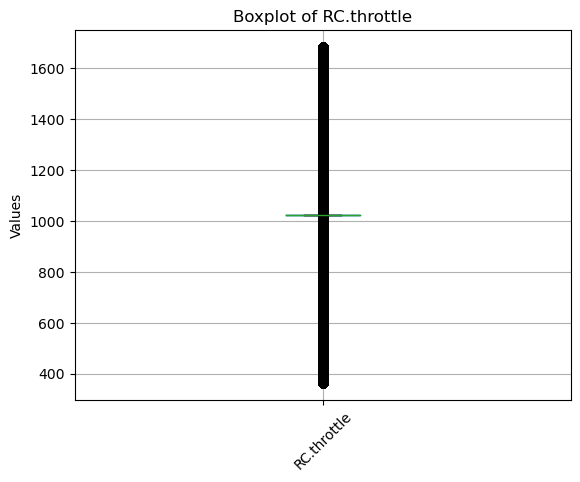

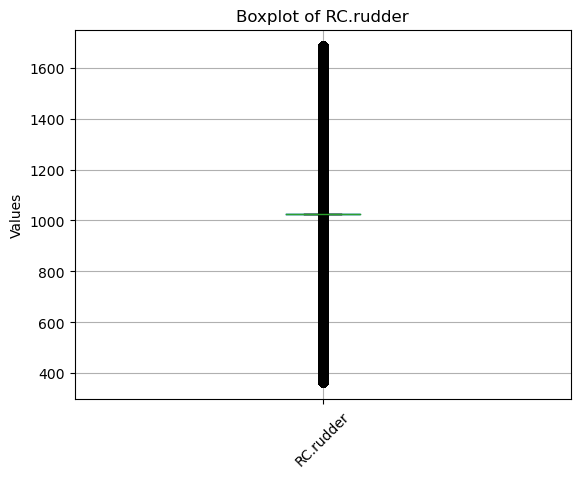

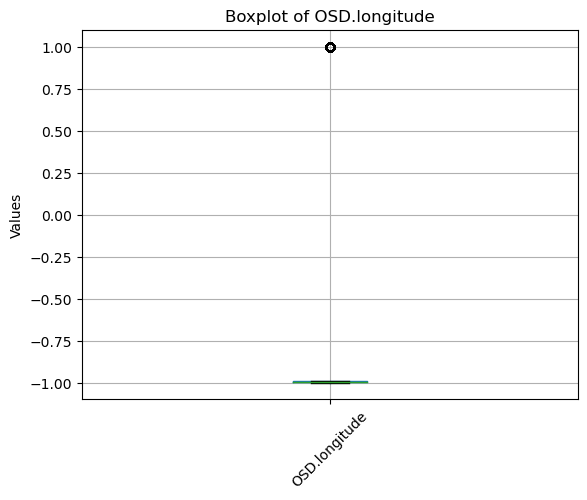

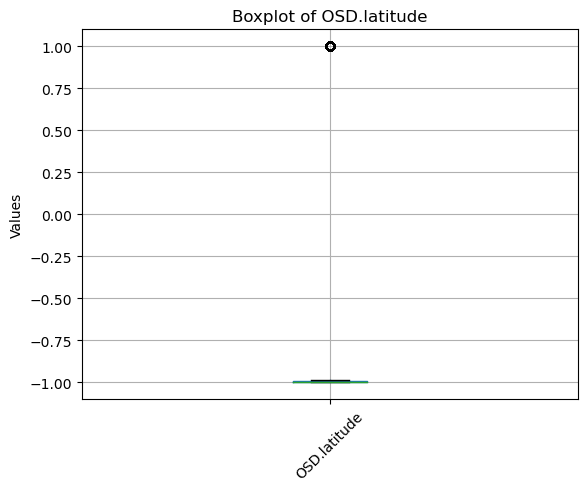

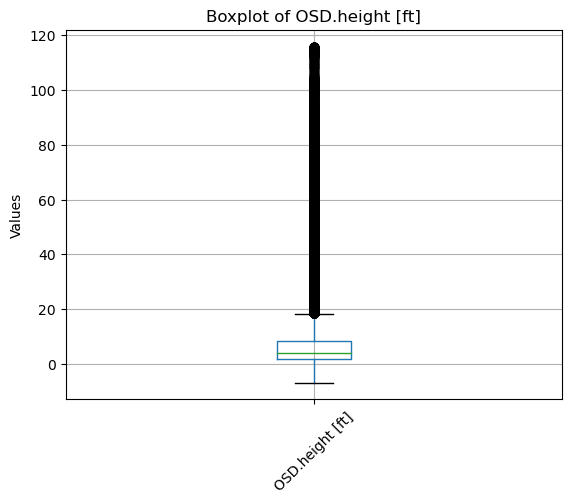

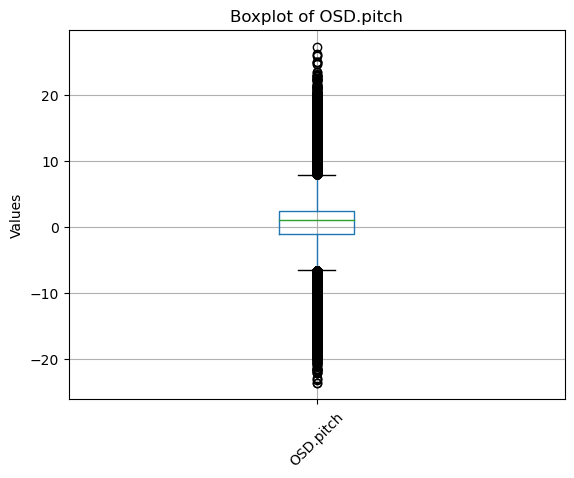

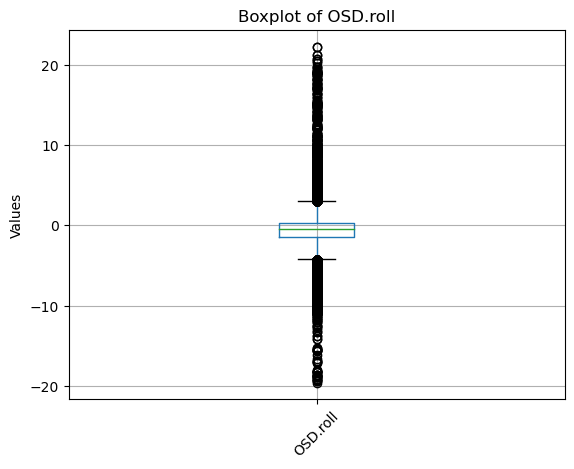

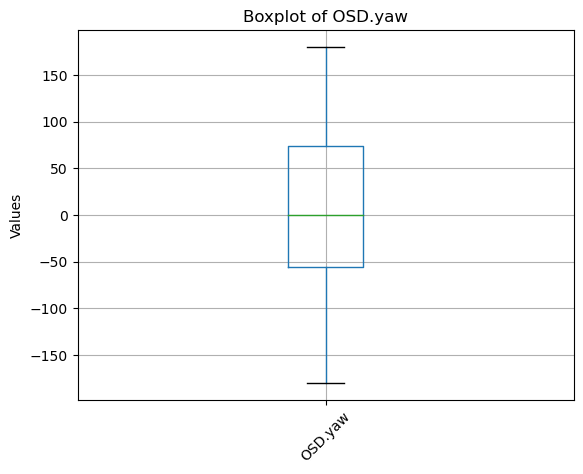

In [49]:
plt.figure(figsize=(15, 10))
for column in df.columns:
    plt.figure()
    df.boxplot(column=[column])
    plt.title(f'Boxplot of {column}')
    plt.ylabel('Values')
    plt.xticks(rotation=45)
    plt.show()

#  calculate outliers before apply  two_sided_median_filter

### Number of outliers for each feature

Number of outliers for each feature:
OSD.flyTime: 0
RC.aileron: 658
RC.elevator: 5430
RC.throttle: 16543
RC.rudder: 16558
OSD.longitude: 2577
OSD.latitude: 2577
OSD.height [ft]: 8518
OSD.pitch: 5338
OSD.roll: 4978
OSD.yaw: 0
Total number of outliers: 63177


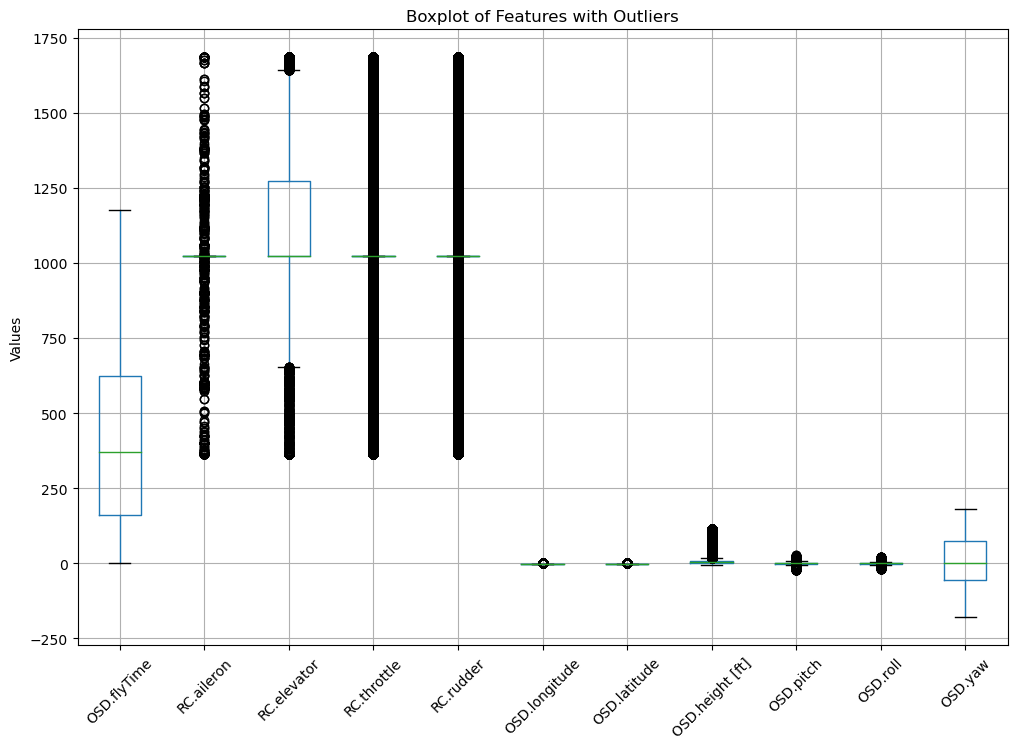

In [50]:
import matplotlib.pyplot as plt

# Initialize an empty dictionary to store the number of outliers for each feature
outliers_count = {}

# Initialize total outliers count
total_outliers_count = 0

# Calculate the first quartile (Q1) and third quartile (Q3) for each feature
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

# Calculate the interquartile range (IQR) for each feature
IQR = Q3 - Q1

# Define the lower and upper bounds for each feature
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Loop through each feature and count the number of outliers
for feature in df.columns:
    outliers_count[feature] = ((df[feature] < lower_bound[feature]) | (df[feature] > upper_bound[feature])).sum()
    total_outliers_count += ((df[feature] < lower_bound[feature]) | (df[feature] > upper_bound[feature])).sum()

# Display the number of outliers for each feature
print("Number of outliers for each feature:")
for feature, count in outliers_count.items():
    print(f"{feature}: {count}")

# Display the total number of outliers
print("Total number of outliers:", total_outliers_count)

# Plot boxplots for each feature
plt.figure(figsize=(12, 8))
df.boxplot()
plt.title("Boxplot of Features with Outliers")
plt.xticks(rotation=45)
plt.ylabel("Values")
plt.show()


### Total outliers by rowise

#### In the first code snippet, outliers are counted for each feature individually, and then the total number of outliers is obtained by summing up these counts. This approach counts the outliers separately for each feature, resulting in a higher total count because it's possible for a data point to be an outlier in multiple features.In the second code snippet, outliers are detected based on whether any feature in a row exceeds the lower or upper bounds. This approach counts the total number of rows with at least one outlier, which may result in a lower total count because each row is counted only once, regardless of how many features in that row contain outliers.

In [51]:
# Calculate the first quartile (Q1) and third quartile (Q3)
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

# Calculate the interquartile range (IQR)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers detection
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = ((df < lower_bound) | (df > upper_bound)).any(axis=1)

# Print number of outliers
print("Number of outliers:", outliers.sum())


Number of outliers: 42023


# Handle the Outliers

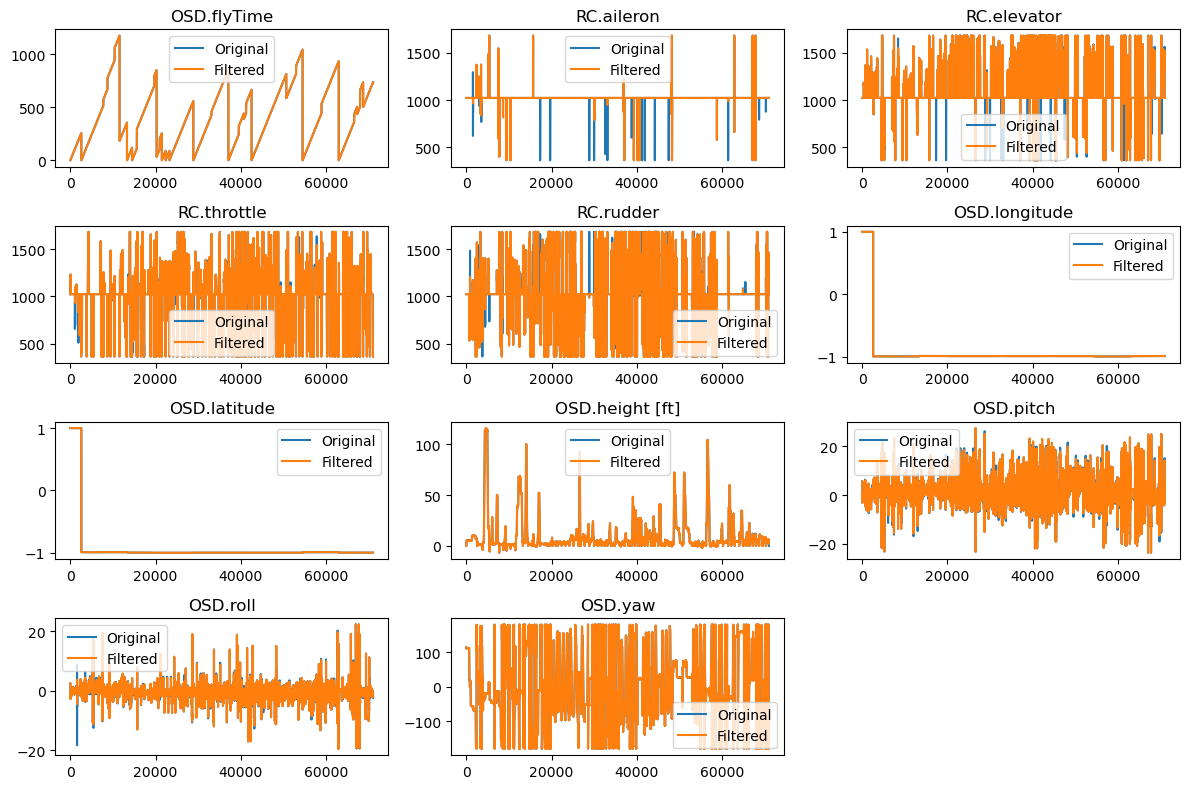

In [52]:
def two_sided_median_filter(data, window_size):
    """
    Perform two-sided median filtering for outlier detection.

    Parameters:
    - data: 1D numpy array containing the flight data
    - window_size: Size of the window for median filtering

    Returns:
    - filtered_data: Numpy array with outliers replaced by the median value of neighboring elements
    """
    filtered_data = np.zeros_like(data)
    half_window = window_size // 2

    for i in range(len(data)):
        lower_bound = max(0, i - half_window)
        upper_bound = min(len(data), i + half_window + 1)

        window = data[lower_bound:upper_bound]
        if len(window) > 0:  # Check if window is not empty
            median = np.median(window)

            if data[i] < median - 1.5 * np.median(np.abs(window - median)):
                filtered_data[i] = median
            elif data[i] > median + 1.5 * np.median(np.abs(window - median)):
                filtered_data[i] = median
            else:
                filtered_data[i] = data[i]
        else:
            # If window is empty, set the filtered value to the original value
            filtered_data[i] = data[i]

    return filtered_data


# Apply two-sided median filtering to each feature
window_size = 7  # You can adjust the window size as needed
for feature in features:
    df[feature + '_filtered'] = two_sided_median_filter(df[feature].values, window_size)

# Plot original and filtered dataa for each feature
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features):
    plt.subplot(4, 3, i+1)
    plt.plot(df[feature], label='Original')
    plt.plot(df[feature + '_filtered'], label='Filtered')
    plt.title(feature)
    plt.legend()
plt.tight_layout()
plt.show()

In [53]:
df.shape

(70998, 22)

# calculate outliers after apply two_sided_median_filter

In [54]:
# Calculate residuals
residuals = np.abs(df[feature] - df[feature + '_filtered'])

# Define threshold (e.g., based on median absolute deviation)
median_absolute_deviation = np.median(residuals)
threshold = 3 * median_absolute_deviation  # Adjust multiplier as needed

# Count outliers
outliers_count = np.sum(residuals > threshold)

print("Number of outliers detected:", outliers_count)


Number of outliers detected: 7074


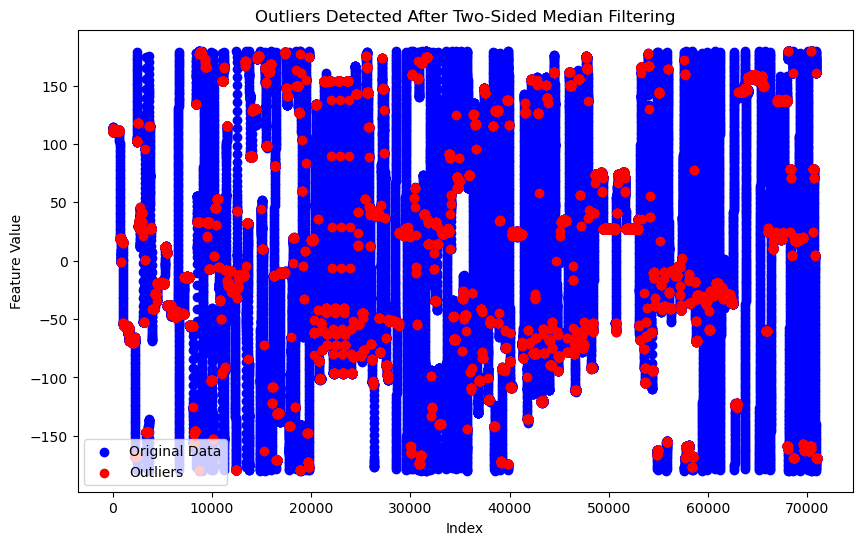

In [55]:
# Calculate residuals
residuals = np.abs(df[feature] - df[feature + '_filtered'])

# Define threshold (e.g., based on median absolute deviation)
median_absolute_deviation = np.median(residuals)
threshold = 3 * median_absolute_deviation  # Adjust multiplier as needed

# Identify outliers
outliers = df[residuals > threshold]

# Visualize outliers
plt.figure(figsize=(10, 6))
plt.scatter(df.index, df[feature], c='blue', label='Original Data')
plt.scatter(outliers.index, outliers[feature], c='red', label='Outliers')
plt.title('Outliers Detected After Two-Sided Median Filtering')
plt.xlabel('Index')
plt.ylabel('Feature Value')
plt.legend()
plt.show()


In [56]:
# Filter outliers
filtered_df = df[residuals <= threshold]

# Display the shape of the filtered DataFrame before and after removing outliers
print("Shape of original DataFrame:", df.shape)
print("Shape of filtered DataFrame (after removing outliers):", filtered_df.shape)


Shape of original DataFrame: (70998, 22)
Shape of filtered DataFrame (after removing outliers): (63924, 22)


In [57]:
df=filtered_df
df=df[features]
df

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
1,0.1,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
2,0.2,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
3,0.3,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.0
4,0.4,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.1
5,0.5,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.1
...,...,...,...,...,...,...,...,...,...,...,...
70992,735.0,1024,1024,364,1024,-0.991804,-0.997564,2.2,2.2,-1.4,-168.8
70993,735.1,1024,1024,364,1024,-0.991804,-0.997565,2.2,2.2,-2.0,-168.8
70994,735.2,1024,1024,364,1024,-0.991804,-0.997565,2.2,2.5,-2.5,-169.0
70995,735.3,1024,1024,364,1024,-0.991804,-0.997565,2.2,2.5,-1.7,-169.2


In [58]:
# Define a function to calculate outliers based on a criterion
def calculate_outliers(data, criterion):
    """
    Calculate outliers based on a criterion.

    Parameters:
    - data: 1D numpy array containing the feature data
    - criterion: Criterion for defining outliers (e.g., threshold value)

    Returns:
    - num_outliers: Number of outliers in the feature data
    """
    # Calculate median or mean of the data
    data_median = np.median(data)
    # Identify outliers based on the criterion
    outliers = data[data > criterion * data_median]
    # Count the number of outliers
    num_outliers = len(outliers)
    return num_outliers

# Define a threshold for identifying outliers (e.g., 1.5 times the median)
threshold = 1.5

# Calculate the number of outliers for each feature
num_outliers_per_feature = {}
for feature in features:
    num_outliers_per_feature[feature] = calculate_outliers(df[feature].values, threshold)

# Print the number of outliers for each feature
for feature, num_outliers in num_outliers_per_feature.items():
    print(f"Number of outliers in {feature}: {num_outliers}")


Number of outliers in OSD.flyTime: 20355
Number of outliers in RC.aileron: 61
Number of outliers in RC.elevator: 5559
Number of outliers in RC.throttle: 1599
Number of outliers in RC.rudder: 3572
Number of outliers in OSD.longitude: 63924
Number of outliers in OSD.latitude: 63924
Number of outliers in OSD.height [ft]: 22280
Number of outliers in OSD.pitch: 27085
Number of outliers in OSD.roll: 37366
Number of outliers in OSD.yaw: 31841


# Normalize other features

In [59]:
# Instantiate the StandardScaler
scaler = StandardScaler()

# Define the columns to normalize
columns_to_normalize = ['OSD.flyTime','RC.aileron','RC.elevator','RC.throttle','RC.rudder','OSD.longitude','OSD.latitude','OSD.height [ft]','OSD.pitch','OSD.roll','OSD.yaw']

# Apply StandardScaler to the specified columns
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])
df.head()

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
1,-1.446710,0.014903,-0.551615,0.130021,-0.020086,5.418035,5.416065,-0.551642,1.207907,1.423261,1.141254
2,-1.446353,0.014903,-0.551615,0.130021,-0.020086,5.418034,5.416066,-0.551642,1.207907,1.423261,1.141254
3,-1.445996,0.014903,-0.551615,0.130021,-0.020086,5.418034,5.416066,-0.551642,1.207907,1.423261,1.141254
4,-1.445639,0.014903,-0.551615,0.130021,-0.020086,5.418033,5.416065,-0.551642,1.207907,1.423261,1.142325
5,-1.445282,0.014903,-0.551615,0.130021,-0.020086,5.418032,5.416066,-0.551642,1.207907,1.423261,1.142325


Range of values for each feature:
                       min        max
OSD.flyTime      -1.447067   2.751898
RC.aileron      -17.087862  17.117668
RC.elevator      -3.410831   2.307601
RC.throttle      -2.716169   2.976211
RC.rudder        -2.749098   2.708925
OSD.longitude    -0.200517   5.418367
OSD.latitude     -0.195580   5.418867
OSD.height [ft]  -0.947176   6.184068
OSD.pitch        -5.924264   6.490096
OSD.roll         -8.440513   9.620552
OSD.yaw          -2.004857   1.846694


<Figure size 1200x600 with 0 Axes>

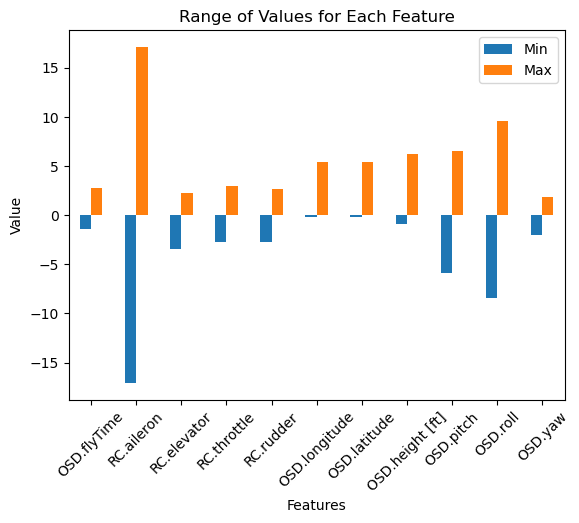

In [60]:
feature_ranges = df.describe().loc[['min', 'max']]

# Transpose the DataFrame for easier plotting
feature_ranges = feature_ranges.transpose()

print("Range of values for each feature:")
print(feature_ranges)
# Plot the range of values for each feature
plt.figure(figsize=(12, 6))
feature_ranges.plot(kind='bar', rot=45)
plt.title('Range of Values for Each Feature')
plt.xlabel('Features')
plt.ylabel('Value')
plt.legend(['Min', 'Max'])
plt.show()

Number of outliers for each feature:
OSD.flyTime: 0
RC.aileron: 575
RC.elevator: 4703
RC.throttle: 14634
RC.rudder: 16267
OSD.longitude: 2106
OSD.latitude: 2106
OSD.height [ft]: 7897
OSD.pitch: 4736
OSD.roll: 4643
OSD.yaw: 0
Total number of outliers: 57667


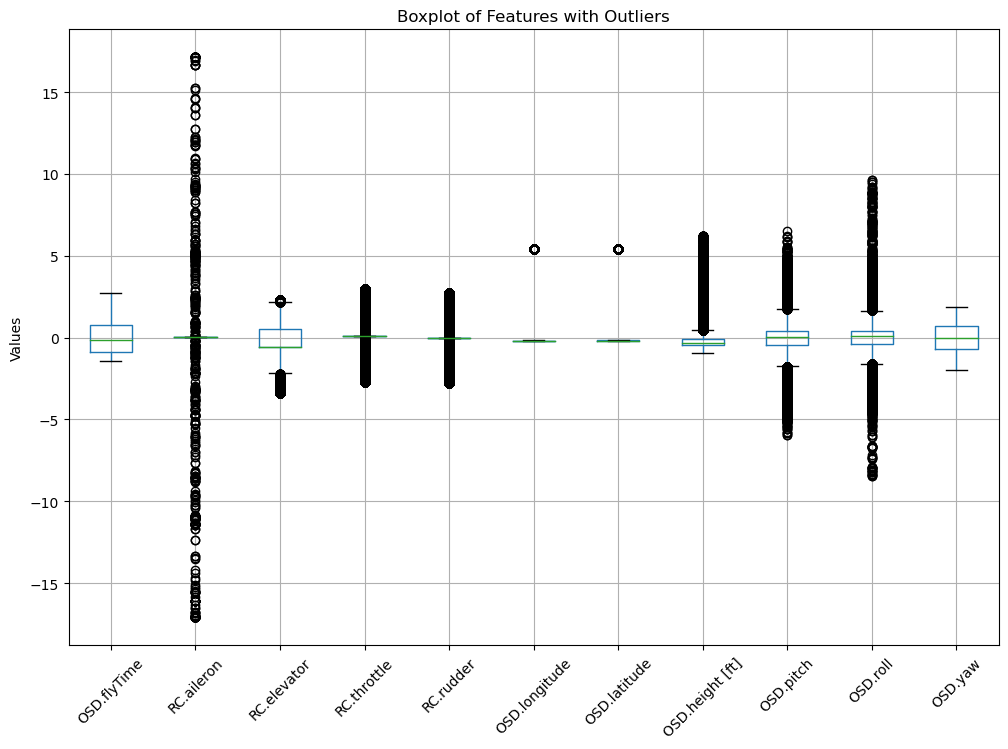

In [61]:
# Initialize an empty dictionary to store the number of outliers for each feature
outliers_count = {}

# Initialize total outliers count
total_outliers_count = 0

# Calculate the first quartile (Q1) and third quartile (Q3) for each feature
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

# Calculate the interquartile range (IQR) for each feature
IQR = Q3 - Q1

# Define the lower and upper bounds for each feature
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Loop through each feature and count the number of outliers
for feature in df.columns:
    outliers_count[feature] = ((df[feature] < lower_bound[feature]) | (df[feature] > upper_bound[feature])).sum()
    total_outliers_count += ((df[feature] < lower_bound[feature]) | (df[feature] > upper_bound[feature])).sum()

# Display the number of outliers for each feature
print("Number of outliers for each feature:")
for feature, count in outliers_count.items():
    print(f"{feature}: {count}")

# Display the total number of outliers
print("Total number of outliers:", total_outliers_count)

# Plot boxplots for each feature
plt.figure(figsize=(12, 8))
df.boxplot()
plt.title("Boxplot of Features with Outliers")
plt.xticks(rotation=45)
plt.ylabel("Values")
plt.show()


# Distribution of each features

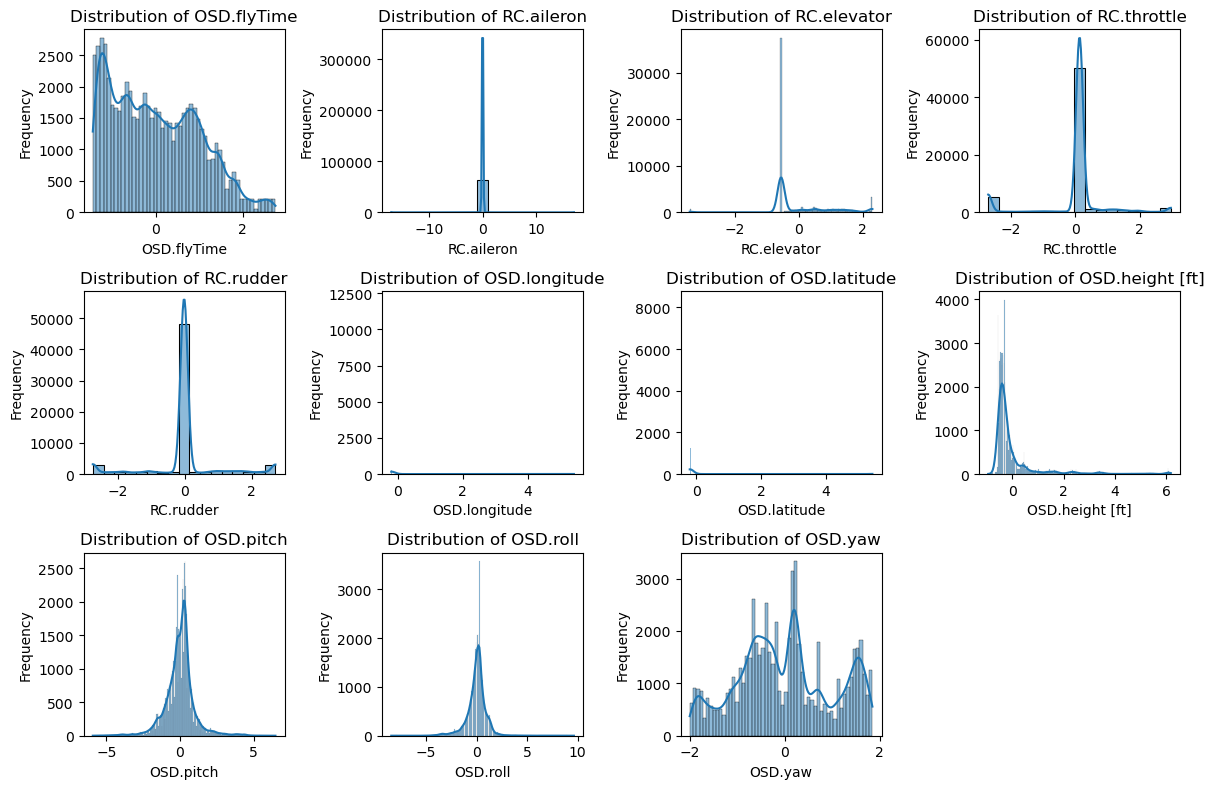

In [62]:
# Plot histograms for each feature
plt.figure(figsize=(12, 8))
for i, feature in enumerate(df.columns):
    plt.subplot(3, 4, i+1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Correlation Matrix:


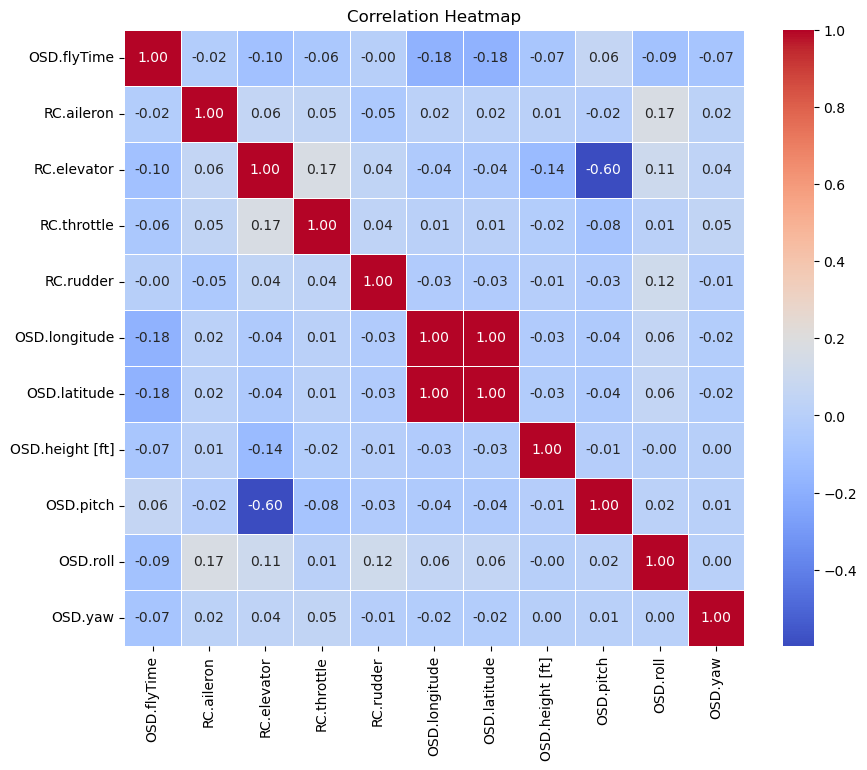

In [63]:
# Calculate correlation matrix
correlation_matrix = df.corr()

# Print correlation matrix
print("Correlation Matrix:")
correlation_matrix

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

#### OSD.flyTime has a weak negative correlation with most variables.RC.aileron has a weak positive correlation with OSD.roll and a weak negative correlation with OSD.pitch.RC.elevator has a moderate positive correlation with OSD.height [ft] and a weak negative correlation with OSD.pitch.RC.throttle has no strong correlation with other variables.RC.rudder has a weak negative correlation with RC.aileron.OSD.longitude and OSD.latitude have a very strong positive correlation, which is expected since they represent coordinates on the same map.OSD.height [ft] has a weak negative correlation with RC.elevator.OSD.pitch has a moderate negative correlation with RC.elevator and a weak negative correlation with OSD.roll.OSD.roll has a weak positive correlation with RC.aileron and OSD.pitch.OSD.yaw has no strong correlation with other variables.

# Build the Neural Network Model

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow import keras
from tensorflow.keras import layers, optimizers
from sklearn.base import BaseEstimator, RegressorMixin

# Selecting relevant features and target variables
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into features and target variables
X = df[input_features]
y = df[output_targets]


# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define a wrapper class for KerasRegressor
class KerasRegressorWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, layers=1, neurons=64, dropout_rate=0.3, learning_rate=0.001, epochs=100, batch_size=32):
        self.layers = layers
        self.neurons = neurons
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.model = None

    def create_model(self):
        model = keras.Sequential()
        model.add(layers.Dense(self.neurons, activation='relu', input_shape=(X_train.shape[1],)))
        model.add(layers.Dropout(self.dropout_rate))
        for _ in range(self.layers - 1):
            model.add(layers.Dense(self.neurons, activation='relu'))
            model.add(layers.Dropout(self.dropout_rate))
        model.add(layers.Dense(len(output_targets)))
        optimizer = optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(optimizer=optimizer, loss='mean_squared_error')
        return model

    def fit(self, X, y):
        self.model = self.create_model()
        self.model.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, verbose=0)
        return self

    def predict(self, X):
        return self.model.predict(X)

# Define hyperparameters to tune
param_dist = {
    'layers': [1, 2, 3], # number of hidden layers
    'neurons': [32, 64, 128], # number of neurons per layer
    'dropout_rate': [0.3, 0.5], # dropout rate
    'learning_rate': [0.001, 0.0001], # learning rate
    'epochs': [50, 100], # number of training epochs
    'batch_size': [32, 64] # batch size
}

# Create KerasRegressor wrapper
model = KerasRegressorWrapper()

# Perform random search
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=10, scoring='neg_mean_squared_error', cv=3, verbose=2, random_state=42, n_jobs=1)

random_search.fit(X_train, y_train)

# Print best parameters and best score
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

# Extract results from random search
results = pd.DataFrame(random_search.cv_results_)

# Define hyperparameters to plot
hyperparameters = ['param_layers', 'param_neurons', 'param_dropout_rate', 'param_learning_rate',
                   'param_epochs', 'param_batch_size']

# Plot random search results
plt.figure(figsize=(12, 12))
for i, param in enumerate(hyperparameters):
    plt.subplot(3, 2, i+1)
    sns.boxplot(x=param, y='mean_test_score', data=results, ax=plt.gca())
    plt.title(f'Random Search CV - {param}')
    plt.xlabel(param)
    plt.ylabel('Mean Test Score')
plt.tight_layout()
plt.show()


# Training the Nerual Network Model

In [134]:
# Selecting relevant features and target variables
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into features and target variables
X = df[input_features]
y = df[output_targets]

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build the model using best parameters
model = keras.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(layers.Dropout(0.3))
for _ in range(2):
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.3))
model.add(layers.Dense(len(output_targets)))

# Compile the model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_split=0.2, verbose=1)

# Evaluate the model
mse = model.evaluate(X_test, y_test, verbose=0)
print("Test Mean Squared Error:", mse)

Epoch 1/100
640/640 [==============================] - 5s 5ms/step - loss: 0.9211 - val_loss: 0.8877
Epoch 2/100
640/640 [==============================] - 2s 4ms/step - loss: 0.8760 - val_loss: 0.8678
Epoch 3/100
640/640 [==============================] - 2s 4ms/step - loss: 0.8520 - val_loss: 0.8400
Epoch 4/100
640/640 [==============================] - 2s 4ms/step - loss: 0.8342 - val_loss: 0.8275
Epoch 5/100
640/640 [==============================] - 2s 4ms/step - loss: 0.8221 - val_loss: 0.8087
Epoch 6/100
640/640 [==============================] - 2s 4ms/step - loss: 0.8116 - val_loss: 0.8043
Epoch 7/100
640/640 [==============================] - 2s 4ms/step - loss: 0.8064 - val_loss: 0.7972
Epoch 8/100
640/640 [==============================] - 2s 4ms/step - loss: 0.7993 - val_loss: 0.7996
Epoch 9/100
640/640 [==============================] - 2s 4ms/step - loss: 0.7974 - val_loss: 0.7906
Epoch 10/100
640/640 [==============================] - 2s 4ms/step - loss: 0.7943 - val_lo

OSD.longitude - Mean Squared Error: 77.48, R-squared: -22.20%, Mean Absolute Error: 3.95, Variance Explained: -22.20%
OSD.latitude - Mean Squared Error: 34.84, R-squared: -6.11%, Mean Absolute Error: 3.02, Variance Explained: -6.11%
OSD.height [ft] - Mean Squared Error: 67.75, R-squared: -462.68%, Mean Absolute Error: 7.48, Variance Explained: -462.68%
OSD.pitch - Mean Squared Error: 11.03, R-squared: -4.14%, Mean Absolute Error: 2.30, Variance Explained: -4.14%
OSD.roll - Mean Squared Error: 15.48, R-squared: -43.72%, Mean Absolute Error: 2.55, Variance Explained: -43.72%
OSD.yaw - Mean Squared Error: 2871.30, R-squared: -10.51%, Mean Absolute Error: 36.27, Variance Explained: -10.51%


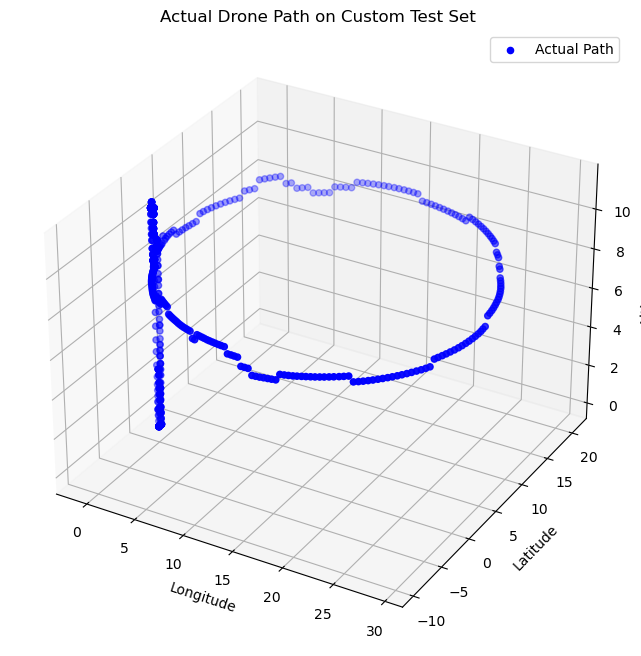

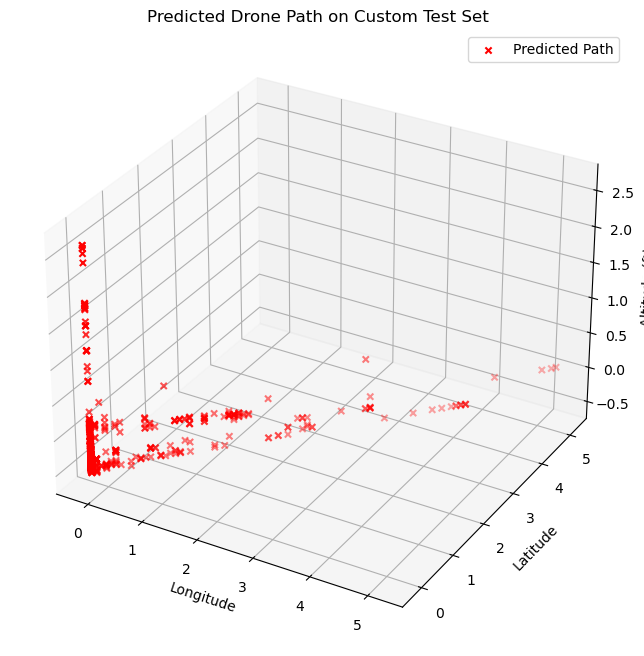

In [435]:
import os
import math
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Define a function to convert latitude and longitude to local Cartesian coordinates
def convert_to_cartesian(row, origin_lat, origin_lon):
    # Calculate the differences between the current point and the origin
    delta_lat = row['OSD.latitude'] - origin_lat
    delta_lon = row['OSD.longitude'] - origin_lon

    lat_to_m = 111320.0  # meters per degree of latitude at the equator
    lon_to_m = 111320.0 * abs(math.cos(math.radians(origin_lat)))  # meters per degree of longitude
    
    # Calculate the x and y coordinates in meters
    x = delta_lon * lon_to_m
    y = delta_lat * lat_to_m
    
    return pd.Series([x, y])  # Return a Series with two values

# Read the custom test dataset
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Preprocess 'OSD.flyTime' column in the test dataset
df_test_custom['OSD.flyTime'] = df_test_custom['OSD.flyTime'].apply(time_to_seconds)

# Define your local projection origin point
origin_lat = df_test_custom['OSD.latitude'].iloc[0]  # Latitude of the first point in the DataFrame
origin_lon = df_test_custom['OSD.longitude'].iloc[0]  # Longitude of the first point in the DataFrame

# Apply the conversion function to each row and create new columns for local Cartesian coordinates
df_test_custom[['local_x', 'local_y']] = df_test_custom.apply(convert_to_cartesian, args=(origin_lat, origin_lon), axis=1)

# Keep the latitude and longitude columns and replace their values with 'local_x' and 'local_y' respectively
df_test_custom['OSD.latitude'] = df_test_custom['local_x']
df_test_custom['OSD.longitude'] = df_test_custom['local_y']

# Drop the 'local_x' and 'local_y' columns if needed
df_test_custom.drop(columns=['local_x', 'local_y'], inplace=True)


features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder','OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']
df_test_custom=df_test_custom[features]

# Normalization using StandardScaler
scaler = StandardScaler()
df_test_custom_scaled = scaler.fit_transform(df_test_custom)

X_test_custom_scaled = df_test_custom_scaled[:, :5]  # Select the first 5 columns after scaling


# Make predictions on the custom test set
y_pred_custom = model.predict(X_test_custom_scaled)

# Calculate and display accuracy metrics for each target variable on the custom test set
for i, target_variable in enumerate(output_targets):
    mse_custom = mean_squared_error(df_test_custom[target_variable], y_pred_custom[:, i])
    r2_custom = r2_score(df_test_custom[target_variable], y_pred_custom[:, i])
    mae_custom = mean_absolute_error(df_test_custom[target_variable], y_pred_custom[:, i])
    variance_explained_custom = 100 * (1 - mse_custom / np.var(df_test_custom[target_variable]))
    
    print(f'{target_variable} - Mean Squared Error: {mse_custom:.2f}, R-squared: {r2_custom:.2%}, Mean Absolute Error: {mae_custom:.2f}, Variance Explained: {variance_explained_custom:.2f}%')


# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.height [ft]'], c='blue', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()

# Create a 3D plot for the predicted drone path on custom test set
fig_predicted_custom = plt.figure(figsize=(12, 8))
ax_predicted_custom = fig_predicted_custom.add_subplot(111, projection='3d')
ax_predicted_custom.scatter(y_pred_custom[:, 0], y_pred_custom[:, 1], y_pred_custom[:, 2], c='red', marker='x', label='Predicted Path')
ax_predicted_custom.set_xlabel('Longitude')
ax_predicted_custom.set_ylabel('Latitude')
ax_predicted_custom.set_zlabel('Altitude (ft)')
ax_predicted_custom.set_title('Predicted Drone Path on Custom Test Set')
ax_predicted_custom.legend()

# Show the actual and predicted path plots on the custom test set
plt.show()



Feature Importance:
       Feature  Importance
0  OSD.flyTime    0.579999
2  RC.elevator    0.192756
4    RC.rudder    0.109889
3  RC.throttle    0.092993
1   RC.aileron    0.024364


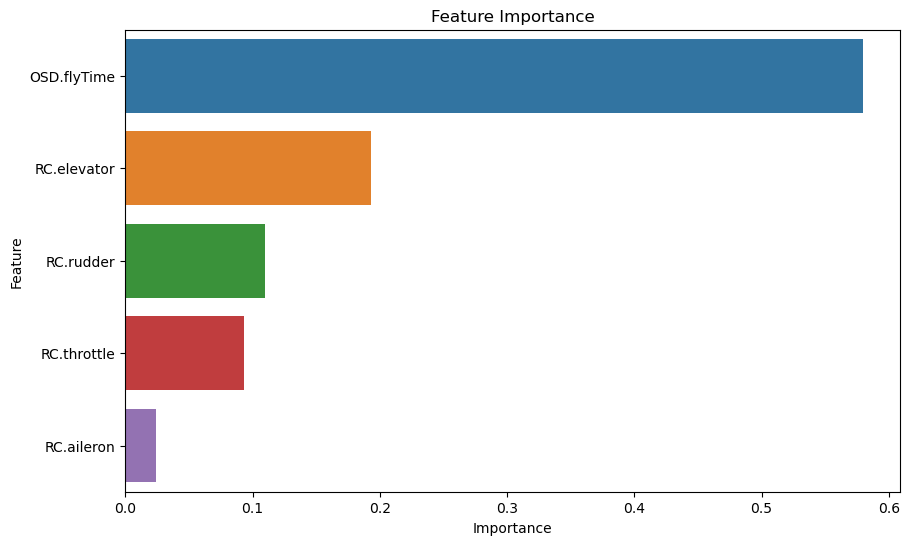

In [434]:
# Train a model with feature importances (example: RandomForestRegressor)
from sklearn.ensemble import RandomForestRegressor

# Define and fit the model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Get feature importances
feature_importances = model.feature_importances_

# Create a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({'Feature': input_features, 'Importance': feature_importances})

# Sort the DataFrame by feature importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the sorted DataFrame
print("Feature Importance:")
print(feature_importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


# LSTM

In [67]:
import numpy as np
import pandas as pd
import os
import math
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.base import BaseEstimator, RegressorMixin

input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into features and target variables
X = df[input_features]
y = df[output_targets]

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Reshape input data for LSTM
X_train_lstm = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Define the LSTM model
def create_lstm_model(layers=1, neurons=64, dropout_rate=0.3, learning_rate=0.001):
    model = Sequential()
    model.add(LSTM(units=neurons, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
    model.add(Dense(units=len(output_targets)))
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

# Define a wrapper class for the LSTM model
class KerasRegressorWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, layers=1, neurons=64, dropout_rate=0.3, learning_rate=0.001):
        self.layers = layers
        self.neurons = neurons
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.model = None

    def fit(self, X, y):
        self.model = create_lstm_model(layers=self.layers, neurons=self.neurons, dropout_rate=self.dropout_rate, learning_rate=self.learning_rate)
        self.model.fit(X, y, epochs=50, batch_size=32, verbose=0)
        return self

    def predict(self, X):
        return self.model.predict(X)

# Create the hyperparameter grid
param_dist = {
    'layers': [1, 2, 3],
    'neurons': [32, 64, 128],
    'dropout_rate': [0.3, 0.5],
    'learning_rate': [0.001, 0.0001]
}

# Perform random search
random_search = RandomizedSearchCV(estimator=KerasRegressorWrapper(), param_distributions=param_dist, n_iter=10, scoring='neg_mean_squared_error', cv=3, verbose=2, random_state=42, n_jobs=1)

random_search.fit(X_train_lstm, y_train)

# Print best parameters and best score
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

# Make predictions with best model
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_lstm)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
533/533 [==============================] - 2s 2ms/step
[CV] END dropout_rate=0.5, layers=3, learning_rate=0.0001, neurons=128; total time= 3.0min
533/533 [==============================] - 2s 2ms/step
[CV] END dropout_rate=0.5, layers=3, learning_rate=0.0001, neurons=128; total time= 3.1min
533/533 [==============================] - 2s 3ms/step
[CV] END dropout_rate=0.5, layers=3, learning_rate=0.0001, neurons=128; total time= 3.0min
533/533 [==============================] - 2s 2ms/step
[CV] END dropout_rate=0.3, layers=3, learning_rate=0.001, neurons=64; total time= 2.6min
533/533 [==============================] - 2s 2ms/step
[CV] END dropout_rate=0.3, layers=3, learning_rate=0.001, neurons=64; total time= 2.5min
533/533 [==============================] - 2s 2ms/step
[CV] END dropout_rate=0.3, layers=3, learning_rate=0.001, neurons=64; total time= 2.5min
533/533 [==============================] - 3s 4ms/step
[CV] END dropo

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into features and target variables
X = df[input_features]
y = df[output_targets]

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Reshape input data for LSTM
# Assuming X_train and X_test are already defined
X_train_lstm = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Define the LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(units=64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model_lstm.add(Dense(units=len(output_targets)))  # Output layer

# Compile the model
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model_lstm.fit(X_train_lstm, y_train, epochs=50, batch_size=32, verbose=1)

# Evaluate the model
mse_lstm = model_lstm.evaluate(X_test_lstm, y_test)

# Make predictions
y_pred_lstm = model_lstm.predict(X_test_lstm)




Epoch 1/50

1599/1599 [==============================] - 9s 3ms/step - loss: 0.8957
Epoch 2/50
1599/1599 [==============================] - 5s 3ms/step - loss: 0.8747
Epoch 3/50
1599/1599 [==============================] - 5s 3ms/step - loss: 0.8660
Epoch 4/50
1599/1599 [==============================] - 6s 4ms/step - loss: 0.8565
Epoch 5/50
1599/1599 [==============================] - 6s 4ms/step - loss: 0.8470
Epoch 6/50
1599/1599 [==============================] - 5s 3ms/step - loss: 0.8381
Epoch 7/50
1599/1599 [==============================] - 5s 3ms/step - loss: 0.8296
Epoch 8/50
1599/1599 [==============================] - 6s 4ms/step - loss: 0.8228
Epoch 9/50
1599/1599 [==============================] - 6s 4ms/step - loss: 0.8172
Epoch 10/50
1599/1599 [==============================] - 5s 3ms/step - loss: 0.8128
Epoch 11/50
1599/1599 [==============================] - 5s 3ms/step - loss: 0.8089
Epoch 12/50
1599/1599 [==============================] - 5s 3ms/step - loss: 0.805

In [69]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split

# Assuming df, input_features, and output_targets are defined

# Splitting the dataset into features and target variables
X = df[input_features]
y = df[output_targets]

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Reshape input data for LSTM
X_train_lstm = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Define the LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(units=128, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), dropout=0.3, recurrent_dropout=0.3, return_sequences=True))
model_lstm.add(LSTM(units=128, dropout=0.3, recurrent_dropout=0.3))
model_lstm.add(Dense(units=len(output_targets)))  # Output layer

# Compile the model
model_lstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
model_lstm.fit(X_train_lstm, y_train, epochs=50, batch_size=32, verbose=1)

# Evaluate the model
mse_lstm = model_lstm.evaluate(X_test_lstm, y_test)

# Make predictions
y_pred_lstm = model_lstm.predict(X_test_lstm)


Epoch 1/50
1599/1599 [==============================] - 23s 9ms/step - loss: 0.9263
Epoch 2/50
1599/1599 [==============================] - 13s 8ms/step - loss: 0.9091
Epoch 3/50
1599/1599 [==============================] - 13s 8ms/step - loss: 0.8973
Epoch 4/50
1599/1599 [==============================] - 12s 7ms/step - loss: 0.8866
Epoch 5/50
1599/1599 [==============================] - 12s 7ms/step - loss: 0.8755
Epoch 6/50
1599/1599 [==============================] - 12s 7ms/step - loss: 0.8669
Epoch 7/50
1599/1599 [==============================] - 12s 7ms/step - loss: 0.8608
Epoch 8/50
1599/1599 [==============================] - 13s 8ms/step - loss: 0.8561
Epoch 9/50
1599/1599 [==============================] - 12s 7ms/step - loss: 0.8529
Epoch 10/50
1599/1599 [==============================] - 12s 8ms/step - loss: 0.8432
Epoch 11/50
1599/1599 [==============================] - 12s 7ms/step - loss: 0.8389
Epoch 12/50
1599/1599 [==============================] - 12s 7ms/step - lo

31/31 [==============================] - 0s 3ms/step
OSD.longitude - Mean Squared Error: 8.75, R-squared: -12.76%, Mean Absolute Error: 2.19, Variance Explained: -12.76%
OSD.latitude - Mean Squared Error: 8.70, R-squared: -204.45%, Mean Absolute Error: 2.54, Variance Explained: -204.45%
OSD.height [ft] - Mean Squared Error: 2.59, R-squared: -348.51%, Mean Absolute Error: 1.48, Variance Explained: -348.51%
OSD.pitch - Mean Squared Error: 5.64, R-squared: -11.71%, Mean Absolute Error: 1.62, Variance Explained: -11.71%
OSD.roll - Mean Squared Error: 0.93, R-squared: -7.32%, Mean Absolute Error: 0.80, Variance Explained: -7.32%
OSD.yaw - Mean Squared Error: 9213.45, R-squared: -18.32%, Mean Absolute Error: 82.60, Variance Explained: -18.32%


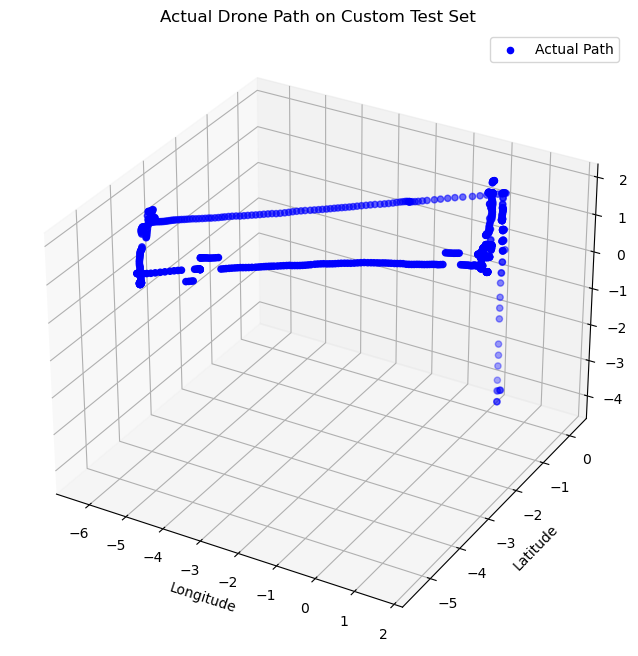

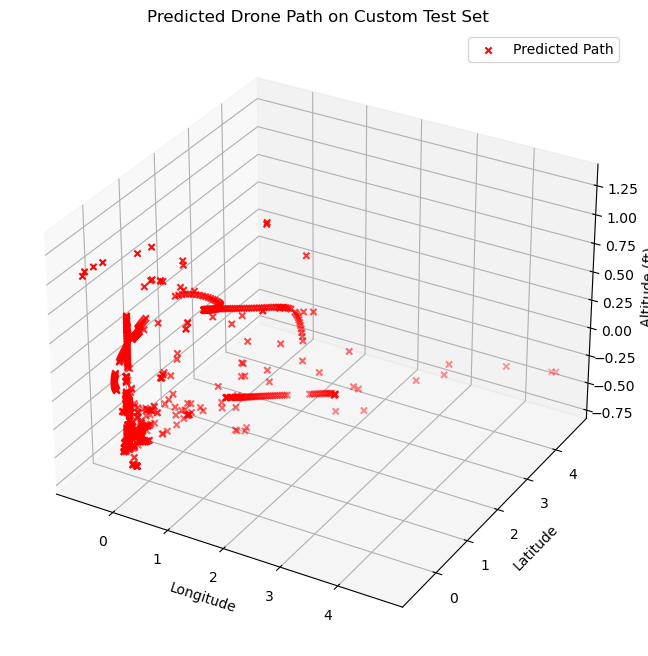

In [84]:
import os
import math
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split

input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Define a function to convert latitude and longitude to local Cartesian coordinates
def convert_to_cartesian(row, origin_lat, origin_lon):
    # Calculate the differences between the current point and the origin
    delta_lat = row['OSD.latitude'] - origin_lat
    delta_lon = row['OSD.longitude'] - origin_lon

    lat_to_m = 111320.0  # meters per degree of latitude at the equator
    lon_to_m = 111320.0 * abs(math.cos(math.radians(origin_lat)))  # meters per degree of longitude
    
    # Calculate the x and y coordinates in meters
    x = delta_lon * lon_to_m
    y = delta_lat * lat_to_m
    
    return pd.Series([x, y])  # Return a Series with two values

# Read the custom test dataset
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Preprocess 'OSD.flyTime' column in the test dataset
df_test_custom['OSD.flyTime'] = df_test_custom['OSD.flyTime'].apply(time_to_seconds)

# Define your local projection origin point
origin_lat = df_test_custom['OSD.latitude'].iloc[0]  # Latitude of the first point in the DataFrame
origin_lon = df_test_custom['OSD.longitude'].iloc[0]  # Longitude of the first point in the DataFrame

# Apply the conversion function to each row and create new columns for local Cartesian coordinates
df_test_custom[['local_x', 'local_y']] = df_test_custom.apply(convert_to_cartesian, args=(origin_lat, origin_lon), axis=1)

# Keep the latitude and longitude columns and replace their values with 'local_x' and 'local_y' respectively
df_test_custom['OSD.latitude'] = df_test_custom['local_x']
df_test_custom['OSD.longitude'] = df_test_custom['local_y']

# Drop the 'local_x' and 'local_y' columns if needed
df_test_custom.drop(columns=['local_x', 'local_y'], inplace=True)


features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder','OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']
df_test_custom=df_test_custom[features]

# Normalization using StandardScaler
scaler = StandardScaler()
df_test_custom_scaled = scaler.fit_transform(df_test_custom[['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder','OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']])

X_test_custom_scaled = df_test_custom_scaled[:, :5]  # Select the first 5 columns after scaling
X_test_custom_lstm = X_test_custom_scaled.reshape((X_test_custom_scaled.shape[0], 1, X_test_custom_scaled.shape[1]))

# Make predictions on the custom test set
y_pred_custom = model_lstm.predict(X_test_custom_lstm)

# Calculate and display accuracy metrics for each target variable on the custom test set
for i, target_variable in enumerate(output_targets):
    mse_custom = mean_squared_error(df_test_custom[target_variable], y_pred_custom[:, i])
    r2_custom = r2_score(df_test_custom[target_variable], y_pred_custom[:, i])
    mae_custom = mean_absolute_error(df_test_custom[target_variable], y_pred_custom[:, i])
    variance_explained_custom = 100 * (1 - mse_custom / np.var(df_test_custom[target_variable]))
    
    print(f'{target_variable} - Mean Squared Error: {mse_custom:.2f}, R-squared: {r2_custom:.2%}, Mean Absolute Error: {mae_custom:.2f}, Variance Explained: {variance_explained_custom:.2f}%')


# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.height [ft]'], c='blue', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()

# Create a 3D plot for the predicted drone path on custom test set
fig_predicted_custom = plt.figure(figsize=(12, 8))
ax_predicted_custom = fig_predicted_custom.add_subplot(111, projection='3d')
ax_predicted_custom.scatter(y_pred_custom[:, 0], y_pred_custom[:, 1], y_pred_custom[:, 2], c='red', marker='x', label='Predicted Path')
ax_predicted_custom.set_xlabel('Longitude')
ax_predicted_custom.set_ylabel('Latitude')
ax_predicted_custom.set_zlabel('Altitude (ft)')
ax_predicted_custom.set_title('Predicted Drone Path on Custom Test Set')
ax_predicted_custom.legend()

# Show the actual and predicted path plots on the custom test set
plt.show()


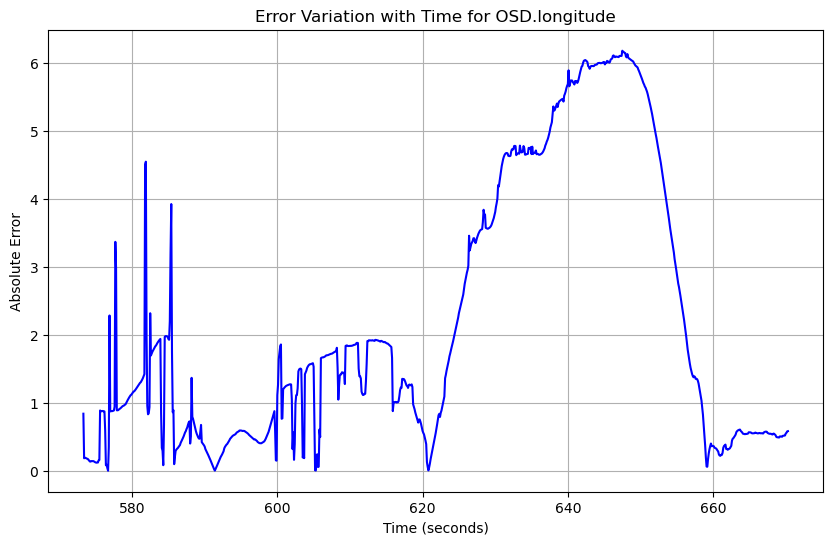

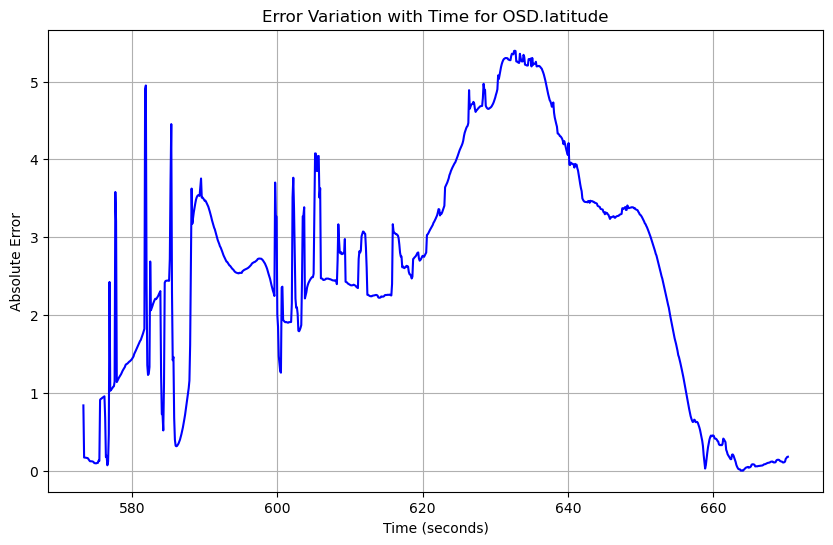

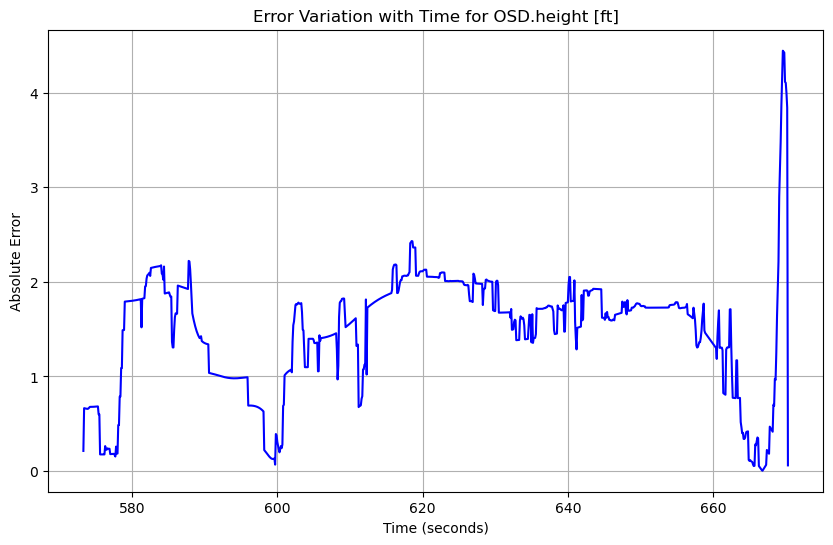

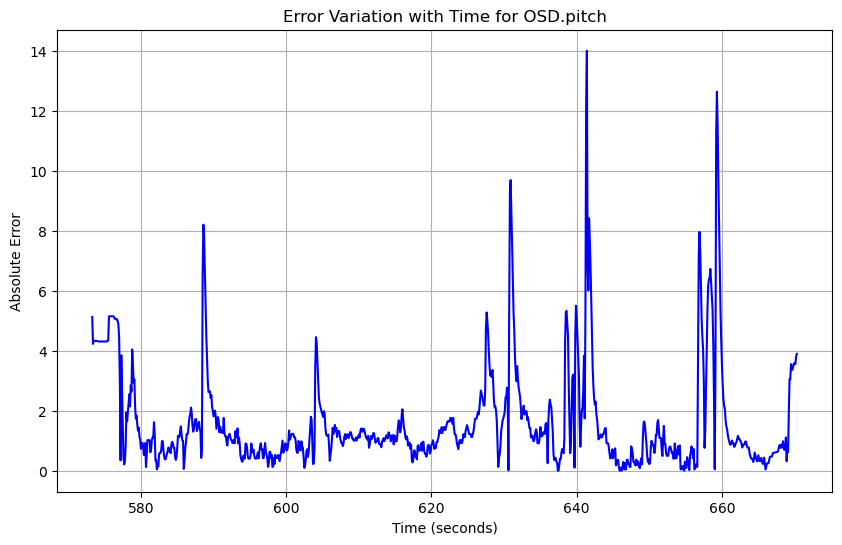

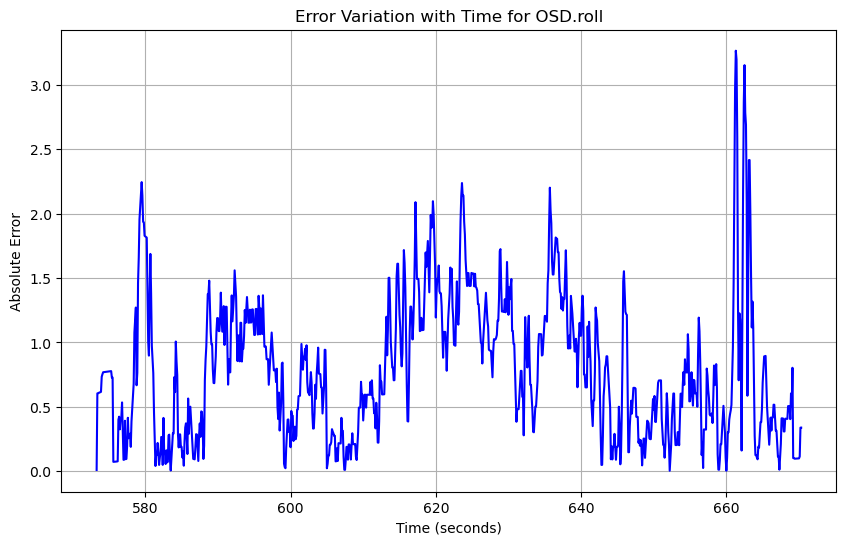

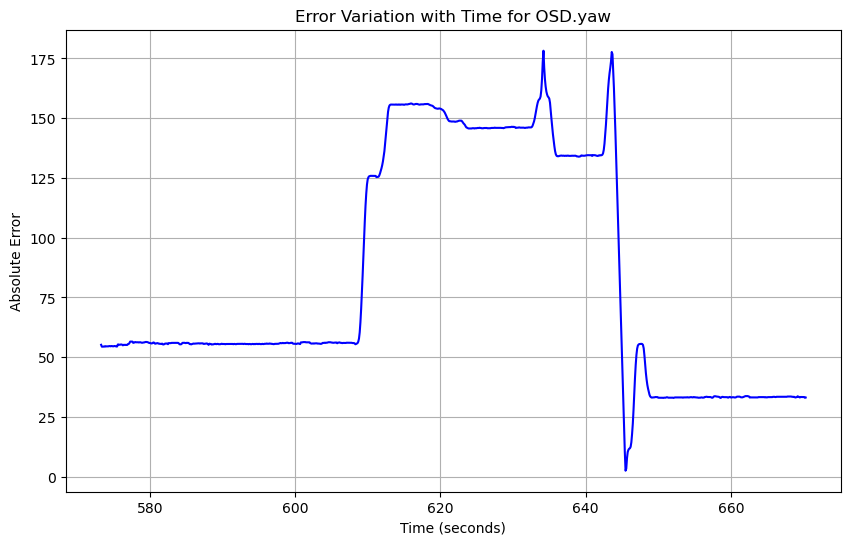

In [85]:
# Calculate the absolute errors for each target variable
absolute_errors_custom = np.abs(y_pred_custom - df_test_custom[output_targets].values)

# Calculate the mean absolute error (MAE) for each target variable
mae_custom_per_variable = np.mean(absolute_errors_custom, axis=0)

# Plot error variation with time for each output variable
for i, target_variable in enumerate(output_targets):
    plt.figure(figsize=(10, 6))
    plt.plot(df_test_custom['OSD.flyTime'], absolute_errors_custom[:, i], color='blue')
    plt.title(f'Error Variation with Time for {target_variable}')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Absolute Error')
    plt.grid(True)
    plt.show()


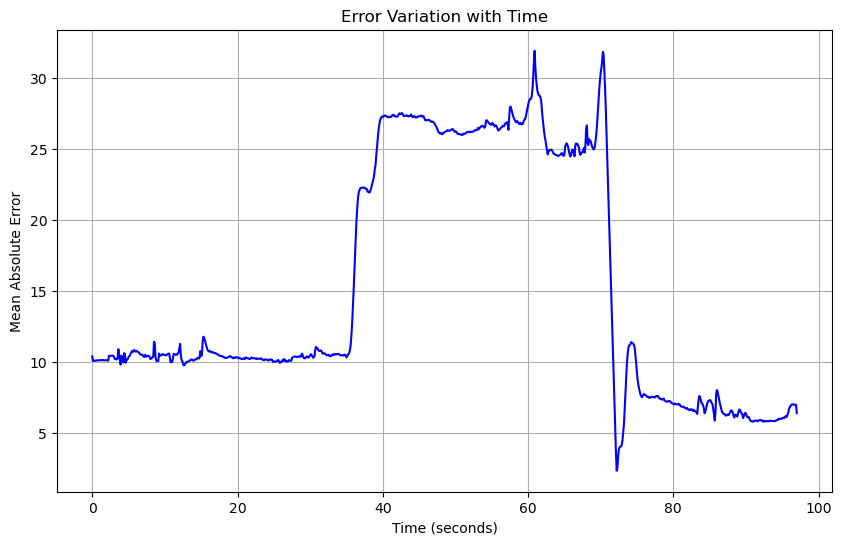

In [80]:
# Calculate the absolute errors for each target variable
absolute_errors_custom = np.abs(y_pred_custom - df_test_custom[output_targets].values)

# Calculate the mean absolute error (MAE) for each time step
mae_time_variation = np.mean(absolute_errors_custom, axis=1)

# Adjust 'OSD.flyTime' to start from zero
adjusted_time = df_test_custom['OSD.flyTime'] - df_test_custom['OSD.flyTime'].min()

# Plot error variation with time
plt.figure(figsize=(10, 6))
plt.plot(adjusted_time, mae_time_variation, color='blue')
plt.title('Error Variation with Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Mean Absolute Error')
plt.grid(True)
plt.show()


In [86]:
df

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
1,-1.446710,0.014903,-0.551615,0.130021,-0.020086,5.418035,5.416065,-0.551642,1.207907,1.423261,1.141254
2,-1.446353,0.014903,-0.551615,0.130021,-0.020086,5.418034,5.416066,-0.551642,1.207907,1.423261,1.141254
3,-1.445996,0.014903,-0.551615,0.130021,-0.020086,5.418034,5.416066,-0.551642,1.207907,1.423261,1.141254
4,-1.445639,0.014903,-0.551615,0.130021,-0.020086,5.418033,5.416065,-0.551642,1.207907,1.423261,1.142325
5,-1.445282,0.014903,-0.551615,0.130021,-0.020086,5.418032,5.416066,-0.551642,1.207907,1.423261,1.142325
...,...,...,...,...,...,...,...,...,...,...,...
70992,1.176617,0.014903,-0.551615,-2.716169,-0.020086,-0.177492,-0.188742,-0.423676,0.355942,-0.333302,-1.886034
70993,1.176974,0.014903,-0.551615,-2.716169,-0.020086,-0.177491,-0.188743,-0.423676,0.355942,-0.603542,-1.886034
70994,1.177331,0.014903,-0.551615,-2.716169,-0.020086,-0.177491,-0.188744,-0.423676,0.428967,-0.828742,-1.888175
70995,1.177688,0.014903,-0.551615,-2.716169,-0.020086,-0.177491,-0.188744,-0.423676,0.428967,-0.468422,-1.890316


# CNN

In [93]:
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.layers import Conv1D, Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, RMSprop
from sklearn.metrics import mean_squared_error
import numpy as np

# Define a function to create the CNN model
def create_model(filters=64, kernel_size=3, activation='relu', optimizer='adam'):
    model = Sequential()
    model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation=activation, input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2])))
    model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation=activation))
    model.add(Flatten())
    model.add(Dense(units=len(output_targets)))  # Output layer
    if optimizer == 'adam':
        optimizer = Adam()
    elif optimizer == 'rmsprop':
        optimizer = RMSprop()
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

# Define the parameter grid
param_grid = {
    'filters': [32, 64, 128],
    'kernel_size': [3, 5],
    'activation': ['relu', 'tanh'],
    'optimizer': ['adam', 'rmsprop']
}

best_mse = np.inf
best_params = {}

# Perform grid search
for filters in param_grid['filters']:
    for kernel_size in param_grid['kernel_size']:
        for activation in param_grid['activation']:
            for optimizer in param_grid['optimizer']:
                print(f'Training model with filters={filters}, kernel_size={kernel_size}, activation={activation}, optimizer={optimizer}')
                model = create_model(filters=filters, kernel_size=kernel_size, activation=activation, optimizer=optimizer)
                model.fit(X_train_cnn, y_train, epochs=50, batch_size=32, verbose=0)
                mse = mean_squared_error(y_test, model.predict(X_test_cnn))
                if mse < best_mse:
                    best_mse = mse
                    best_params = {'filters': filters, 'kernel_size': kernel_size, 'activation': activation, 'optimizer': optimizer}

# Print the best parameters and best MSE
print("Best parameters found: ", best_params)
print("Best Mean Squared Error found: ", best_mse)


Training model with filters=32, kernel_size=3, activation=relu, optimizer=adam
400/400 [==============================] - 1s 2ms/step
Training model with filters=32, kernel_size=3, activation=relu, optimizer=rmsprop
400/400 [==============================] - 1s 2ms/step
Training model with filters=32, kernel_size=3, activation=tanh, optimizer=adam
400/400 [==============================] - 1s 2ms/step
Training model with filters=32, kernel_size=3, activation=tanh, optimizer=rmsprop
400/400 [==============================] - 1s 2ms/step
Training model with filters=32, kernel_size=5, activation=relu, optimizer=adam


ValueError: One of the dimensions in the output is <= 0 due to downsampling in conv1d_17. Consider increasing the input size. Received input shape [None, 1, 32] which would produce output shape with a zero or negative value in a dimension.

In [87]:
from tensorflow.keras.layers import Conv1D, Flatten

# Reshape input data for CNN
X_train_cnn = X_train.values.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn = X_test.values.reshape((X_test.shape[0], X_test.shape[1], 1))

# Define the CNN model
model_cnn = Sequential()
model_cnn.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2])))
model_cnn.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model_cnn.add(Flatten())
model_cnn.add(Dense(units=len(output_targets)))  # Output layer

# Compile the model
model_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
model_cnn.fit(X_train_cnn, y_train, epochs=50, batch_size=32, verbose=1)

# Evaluate the model
mse_cnn = model_cnn.evaluate(X_test_cnn, y_test)

# Make predictions
y_pred_cnn = model_cnn.predict(X_test_cnn)



from sklearn.metrics import r2_score

# Evaluate the model
mse_cnn = model_cnn.evaluate(X_test_cnn, y_test)

# Make predictions
y_pred_cnn = model_cnn.predict(X_test_cnn)

# Calculate and display accuracy metrics for each target variable on the custom test set
for i, target_variable in enumerate(output_targets):
    mse_custom = mean_squared_error(y_test[target_variable], y_pred_cnn[:, i])
    r2_custom = r2_score(y_test[target_variable], y_pred_cnn[:, i])
    mae_custom = mean_absolute_error(y_test[target_variable], y_pred_cnn[:, i])
    variance_explained_custom = 100 * (1 - mse_custom / np.var(y_test[target_variable]))
    
    print(f'{target_variable} - Mean Squared Error: {mse_custom:.2f}, R-squared: {r2_custom:.2%}, Mean Absolute Error: {mae_custom:.2f}, Variance Explained: {variance_explained_custom:.2f}%')

# Model Accuracy
print("CNN Model Accuracy:")
print(f"MSE: {mse_cnn}")



Epoch 1/50
1599/1599 [==============================] - 7s 3ms/step - loss: 0.8565
Epoch 2/50
1599/1599 [==============================] - 6s 4ms/step - loss: 0.8102
Epoch 3/50
1599/1599 [==============================] - 6s 3ms/step - loss: 0.7873
Epoch 4/50
1599/1599 [==============================] - 5s 3ms/step - loss: 0.7727
Epoch 5/50
1599/1599 [==============================] - 5s 3ms/step - loss: 0.7624
Epoch 6/50
1599/1599 [==============================] - 5s 3ms/step - loss: 0.7548
Epoch 7/50
1599/1599 [==============================] - 5s 3ms/step - loss: 0.7485
Epoch 8/50
1599/1599 [==============================] - 5s 3ms/step - loss: 0.7446
Epoch 9/50
1599/1599 [==============================] - 6s 4ms/step - loss: 0.7396
Epoch 10/50
1599/1599 [==============================] - 5s 3ms/step - loss: 0.7368
Epoch 11/50
1599/1599 [==============================] - 5s 3ms/step - loss: 0.7337
Epoch 12/50
1599/1599 [==============================] - 5s 3ms/step - loss: 0.7315
E

31/31 [==============================] - 0s 3ms/step
OSD.longitude - Mean Squared Error (CNN): 8.83, R-squared (CNN): -13.77%, Mean Absolute Error (CNN): 2.28, Variance Explained (CNN): -13.77%
OSD.latitude - Mean Squared Error (CNN): 10.89, R-squared (CNN): -281.02%, Mean Absolute Error (CNN): 2.75, Variance Explained (CNN): -281.02%
OSD.height [ft] - Mean Squared Error (CNN): 3.82, R-squared (CNN): -560.08%, Mean Absolute Error (CNN): 1.84, Variance Explained (CNN): -560.08%
OSD.pitch - Mean Squared Error (CNN): 5.45, R-squared (CNN): -7.81%, Mean Absolute Error (CNN): 1.63, Variance Explained (CNN): -7.81%
OSD.roll - Mean Squared Error (CNN): 1.02, R-squared (CNN): -17.74%, Mean Absolute Error (CNN): 0.85, Variance Explained (CNN): -17.74%
OSD.yaw - Mean Squared Error (CNN): 9262.77, R-squared (CNN): -18.96%, Mean Absolute Error (CNN): 82.94, Variance Explained (CNN): -18.96%


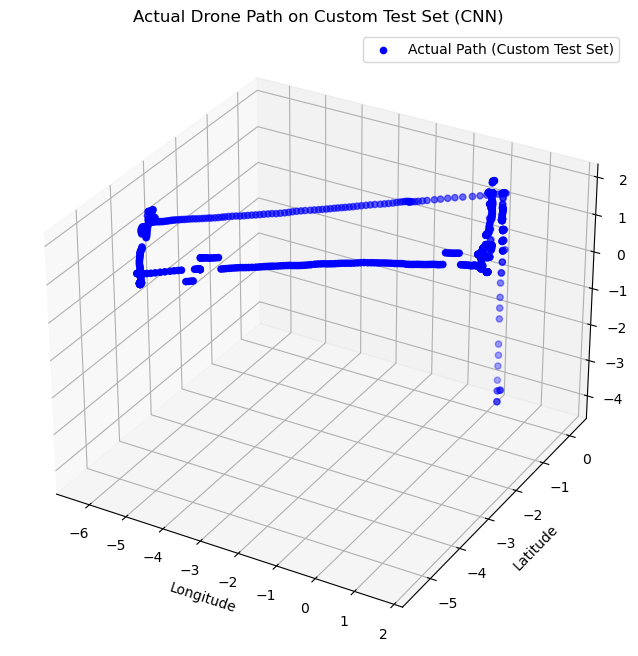

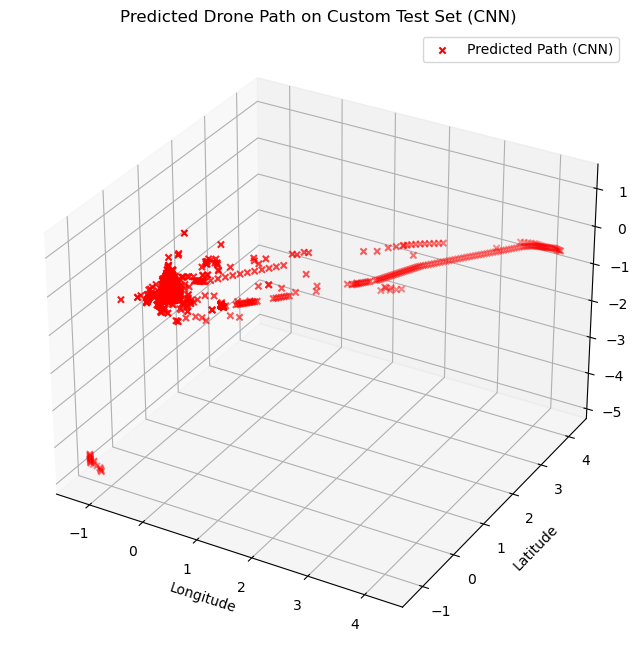

In [90]:
# Make predictions on the custom test set using the CNN model
y_pred_custom_cnn = model_cnn.predict(X_test_custom_scaled.reshape((X_test_custom_scaled.shape[0], X_test_custom_scaled.shape[1], 1)))

# Calculate and display accuracy metrics for each target variable on the custom test set
for i, target_variable in enumerate(output_targets):
    mse_custom_cnn = mean_squared_error(df_test_custom[target_variable], y_pred_custom_cnn[:, i])
    r2_custom_cnn = r2_score(df_test_custom[target_variable], y_pred_custom_cnn[:, i])
    mae_custom_cnn = mean_absolute_error(df_test_custom[target_variable], y_pred_custom_cnn[:, i])
    variance_explained_custom_cnn = 100 * (1 - mse_custom_cnn / np.var(df_test_custom[target_variable]))
    
    print(f'{target_variable} - Mean Squared Error (CNN): {mse_custom_cnn:.2f}, R-squared (CNN): {r2_custom_cnn:.2%}, Mean Absolute Error (CNN): {mae_custom_cnn:.2f}, Variance Explained (CNN): {variance_explained_custom_cnn:.2f}%')

# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom_cnn = plt.figure(figsize=(12, 8))
ax_actual_custom_cnn = fig_actual_custom_cnn.add_subplot(111, projection='3d')
ax_actual_custom_cnn.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.height [ft]'], c='blue', marker='o', label='Actual Path (Custom Test Set)')
ax_actual_custom_cnn.set_xlabel('Longitude')
ax_actual_custom_cnn.set_ylabel('Latitude')
ax_actual_custom_cnn.set_zlabel('Altitude (ft)')
ax_actual_custom_cnn.set_title('Actual Drone Path on Custom Test Set (CNN)')
ax_actual_custom_cnn.legend()

# Create a 3D plot for the predicted drone path on custom test set using the CNN model
fig_predicted_custom_cnn = plt.figure(figsize=(12, 8))
ax_predicted_custom_cnn = fig_predicted_custom_cnn.add_subplot(111, projection='3d')
ax_predicted_custom_cnn.scatter(y_pred_custom_cnn[:, 0], y_pred_custom_cnn[:, 1], y_pred_custom_cnn[:, 2], c='red', marker='x', label='Predicted Path (CNN)')
ax_predicted_custom_cnn.set_xlabel('Longitude')
ax_predicted_custom_cnn.set_ylabel('Latitude')
ax_predicted_custom_cnn.set_zlabel('Altitude (ft)')
ax_predicted_custom_cnn.set_title('Predicted Drone Path on Custom Test Set (CNN)')
ax_predicted_custom_cnn.legend()

# Show the actual and predicted path plots on the custom test set using the CNN model
plt.show()
